# CO<sub>2</sub> Emissions Regression — Portfolio Project

**Author:** Tim  
**Dataset:** Our World in Data – CO<sub>2</sub> and Greenhouse Gas Emissions  
**Objective:** Predict share of global temperature change from energy, economic, and demographic features using multiple regression models.

---

## 1. Introduction

### Problem Statement
CO<sub>2</sub> emissions are the primary driver of anthropogenic climate change. Accurately predicting a country's annual emissions from economic and energy indicators helps policymakers design evidence-based climate targets.

### Goal
Build and compare five regression models to predict a country's Country's share of global temp change.

**Features used:**
- **Energy:** primary energy consumption, coal, oil, gas, cement, flaring emissions
- **Economic:** GDP
- **Demographic:** population
- **Temporal:** year

**Modeling approach:**
1. Linear Regression (baseline)
2. Ridge Regression (L2 regularization)
3. Lasso Regression (L1 — implicit feature selection)
4. Random Forest (bagging ensemble)
5. Gradient Boosting (boosting ensemble)

> **Target variable:** `log(share_of_temperature_change_from_ghg)` — the heavily right-skewed target is log-transformed to stabilise variance and improve linear model performance.

## Step 1: Setup & Imports
**Concept**: Before any data science work begins, you load all the tools (libraries) your project will need. Think of it like gathering all your equipment before starting an experiment.

**Why necessary**:
Libraries help in manipulating the dataset, visualizing data, processing, training, evaluating and saving models.

**What I've learnt**:
Every data science project starts with imports — it's standard practice
Libraries are grouped by purpose (data, visualization, ML) for readability
pd.set_option('display.max_columns', None) ensures you see all columns when previewing the dataframe, not a truncated view

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

# Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Model Persistence
import joblib

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


## Step 2: Load & Explore the Data (EDA)
**Concept**: EDA (Exploratory Data Analysis) is the process of understanding your dataset before touching it. You look at its shape, data types, missing values, and how the target variable is distributed. It's the most important step in any ML project.
**Why necessary:**

You can't make good modeling decisions without first understanding your data
Reveals missing values early so you plan how to handle them
Helps you spot outliers that could skew your model

**Key observations from this dataset**:

some columns can't fit directly into the model
some columns have largely missing values and are likely to be dropped.

What I've learnt:

EDA is not optional — it directly informs every decision you make in later steps
Missing % matters more than missing count — a column missing 80% of its data is usually not worth keeping
Always visualize your target variable first — a heavily skewed target may need log transformation before modeling
df.info() and df.describe() together give you a complete picture of your data's health

In [5]:
URL = 'https://raw.githubusercontent.com/owid/co2-data/refs/heads/master/owid-co2-data.csv'
data = pd.read_csv(URL)
print(f"Shape: {data.shape[0]:,} rows x {data.shape[1]} columns")
data.head()

Shape: 50,411 rows x 79 columns


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Summary statistics
data.describe().T

,count,mean,std,min,25%,50%,75%,max
year,50411.0,1.920349e+03,6.585912e+01,1.750000e+03,1.875000e+03,1.925000e+03,1.975000e+03,2.024000e+03
population,41167.0,6.017453e+07,3.308433e+08,2.150000e+02,3.272140e+05,2.291594e+06,9.986553e+06,8.161973e+09
gdp,15251.0,3.300495e+11,3.086383e+12,4.998000e+07,7.874038e+09,2.743861e+10,1.212627e+11,1.301126e+14
cement_co2,29173.0,7.890109e+00,6.298817e+01,0.000000e+00,0.000000e+00,0.000000e+00,5.240000e-01,1.666885e+03
cement_co2_per_capita,25648.0,6.001252e-02,1.235623e-01,0.000000e+00,0.000000e+00,1.000000e-03,7.625000e-02,2.484000e+00
...,...,...,...,...,...,...,...,...
temperature_change_from_n2o,38280.0,5.090648e-04,3.047886e-03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.500000e-02
total_ghg,38150.0,4.907996e+02,2.414077e+03,-1.972500e+01,1.502000e+00,1.460550e+01,7.650850e+01,5.443340e+04
total_ghg_excluding_lucf,37813.0,3.105215e+02,1.812364e+03,0.000000e+00,2.210000e-01,2.222000e+00,2.786300e+01,4.371478e+04
trade_co2,4712.0,-6.986781e+00,2.590182e+02,-2.177807e+03,-2.262250e+00,1.641000e+00,1.142550e+01,1.768846e+03


In [22]:
# Check for missing values and their percentages
missing = data.isnull().sum()
missing_pct = (missing / len(data)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

                                      Missing Count  Missing %
share_global_cumulative_other_co2             48241      95.70
share_global_other_co2                        48241      95.70
other_co2_per_capita                          47752      94.73
other_industry_co2                            47157      93.55
cumulative_other_co2                          47157      93.55
...                                             ...        ...
population                                     9244      18.34
share_of_temperature_change_from_ghg           9173      18.20
temperature_change_from_co2                    9173      18.20
temperature_change_from_ghg                    9173      18.20
iso_code                                       7931      15.73

[77 rows x 2 columns]


### Step 3: Handling Missing Values
**Concept**: Missing data is when cells in your dataset have no value (NaN).  This dataset contains large missing values and therefore requires efficient strategies to deal with it.

**Why necessary**:
- Most algorithms may not handle missing data well
- Dropping too many columns loses valuable information
- Wrong imputation strategy can bias the model's predictions

**Strategies for this dataset**:
- Drop columns with more than 50% missing data
- Drop target rows with missing values
- Median imputation for remaining numeric columns — median is robust to outliers unlike mean. 
- Drop non-numeric columns (country, iso_code) — handled later in feature engineering

In [23]:
# Always make a copy of the original DataFrame before making any modifications
df_clean = data.copy()

print("Original shape:", data.shape)
print("Working copy shape:", df_clean.shape)

Original shape: (50411, 79)
Working copy shape: (50411, 79)


In [ ]:
# Drop rows without a target value
df_clean = df_clean.dropna(subset=['temperature_change_from_ghg'])

print("Shape after dropping missing target rows:", df_clean.shape)


Shape after dropping missing target rows: (41238, 79)
Columns now: ['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct', 'co2_including_luc_per_capita', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2', 'cumulative_co2_including_luc', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2', 'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2', 'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'land_use_change_co2_per_capita', 'methane', 

In [26]:
# Calculate missing percentage per column
missing_pct = df_clean.isnull().sum() / len(df_clean) * 100

# Identify columns to drop
cols_to_drop = missing_pct[missing_pct > 50].index.tolist()

print(f"Columns to drop ({len(cols_to_drop)}):\n", cols_to_drop)

# Drop them
df_clean = df_clean.drop(columns=cols_to_drop)

print("\nShape after dropping high-missing columns:", df_clean.shape)

Columns to drop (33):
 ['gdp', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_other_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2', 'gas_co2_per_capita', 'other_co2_per_capita', 'other_industry_co2', 'primary_energy_consumption', 'share_global_coal_co2', 'share_global_cumulative_coal_co2', 'share_global_cumulative_flaring_co2', 'share_global_cumulative_gas_co2', 'share_global_cumulative_other_co2', 'share_global_flaring_co2', 'share_global_gas_co2', 'share_global_other_co2', 'trade_co2', 'trade_co2_share']

Shape after dropping high-missing columns: (41238, 46)


In [27]:
# Drop text columns - can't impute or use directly in regression
df_clean = df_clean.drop(columns=['country', 'iso_code'], errors='ignore')

print("Shape after dropping text columns:", df_clean.shape)
print("\nRemaining dtypes:\n", df_clean.dtypes.value_counts())

Shape after dropping text columns: (41238, 44)

Remaining dtypes:
 float64    43
int64       1
Name: count, dtype: int64


In [28]:
# Fill remaining NaN values with each column's median
imputer = SimpleImputer(strategy='median')

df_clean = pd.DataFrame(
    imputer.fit_transform(df_clean),
    columns=df_clean.columns
)

# Confirm no missing values remain
print("Missing values remaining:", df_clean.isnull().sum().sum())
print("Final shape:", df_clean.shape)

Missing values remaining: 0
Final shape: (41238, 44)


In [31]:
# Summary statistics of the cleaned DataFrame
df_clean.describe()


,year,population,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_per_capita,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_luc_co2,cumulative_oil_co2,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_luc_co2,share_global_oil_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf
count,41238.000000,4.123800e+04,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,4.123800e+04,4.123800e+04,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000
mean,1937.500000,5.538298e+07,5.601468,0.040428,212.193189,4.105575,28.172190,325.651621,4.312141,2.863435,6.016152,2.910192,139.126946,8.336843e+03,1.654409e+04,9112.893026,2315.805353,2.764684,7.279012,113.306842,3.588686,88.265711,1.649548,23.769551,0.418372,70.814928,1.515136,1.635170,2.142370,2.060048,1.628503,2.218635,1.968256,2.322253,1.951485,2.210034,1.940886,2.272236,0.002665,0.008014,0.011224,0.000473,454.674792,284.835475
std,50.229253,3.267138e+08,53.097762,0.100612,1425.119011,50.568791,1373.195747,1745.490756,75.202799,126.036727,6.857228,11.538512,1260.869647,6.006621e+04,9.734747e+04,43965.688950,19629.784916,7.303361,10.523692,496.259379,8.548470,418.750513,3.592746,125.659794,0.745073,510.682379,10.831519,9.950763,10.592387,9.018151,10.001099,11.281208,8.983101,9.313381,10.211423,9.337716,10.036540,9.282343,0.014820,0.045687,0.062888,0.002939,2325.209329,1737.556681
min,1851.000000,2.220000e+02,0.000000,0.000000,0.000000,-1928.339000,-100.000000,-84.560000,-2298.978000,-11927.241000,-12.455000,0.000000,0.000000,0.000000e+00,-1.203450e+02,-3918.006000,0.000000,0.022000,-28.852000,-319.418000,-45.317000,0.000000,0.032000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.375000,0.000000,0.000000,-0.101000,-0.518000,0.000000,-6.966000,0.000000,-0.824000,-0.001000,0.000000,-0.001000,0.000000,-19.725000,0.000000
25%,1894.000000,4.882140e+05,0.002000,0.002000,2.077250,0.011000,2.113250,20.221250,0.015000,0.390250,3.762250,0.691000,0.058000,3.593800e+01,6.834832e+02,30.099500,16.456000,0.309000,2.203000,0.133000,0.234000,0.532000,0.681000,0.091000,0.125000,0.974250,0.305000,0.019000,0.022000,0.125000,0.014000,0.012000,0.096000,0.016000,0.031000,0.003000,0.038000,0.003000,0.000000,0.000000,0.000000,0.000000,2.101250,0.287250
50%,1937.500000,2.536365e+06,0.046000,0.007000,4.644000,0.051000,3.897000,28.127000,0.112000,1.183000,4.536000,1.181000,0.538000,9.189800e+01,1.045753e+03,303.724000,31.563000,0.665000,4.291000,3.578000,1.301000,3.492000,1.007000,0.715000,0.225000,1.764000,0.469500,0.029000,0.051000,0.175000,0.023000,0.029000,0.143000,0.109000,0.056000,0.076500,0.065000,0.081000,0.000000,0.000000,0.000000,0.000000,14.727500,2.265000
75%,1981.000000,8.537978e+06,0.127000,0.016000,10.058500,0.179000,5.562000,39.694750,0.326750,2.021000,5.430750,2.006000,1.716750,2.276095e+02,1.574702e+03,1436.564250,58.532000,2.212750,8.224250,19.111000,3.568000,15.694000,1.561000,4.501750,0.414000,2.924000,0.7

#### What I've learnt:

- Always make a copy of the original dataframe before any manipulation — df.copy() not df_clean = df(that just creates a reference, not a true copy)
- Drop target-missing rows before anything else — no point cleaning what you can't use
- The 50% threshold for dropping columns is a common industry rule of thumb, not a fixed law — context matters
- SimpleImputer from sklearn is cleaner than data.fillna() because it integrates directly into sklearn pipelines later
errors='ignore' in drop() prevents crashes if a column name doesn't exist

## Step 4: Feature Selection
**Concept**: Feature selection is the process of choosing only the most relevant columns (features) to feed into your model. Not every column in the dataset helps the model learn — some are redundant, some are too similar to the target, and some just add noise.

**Why necessary**:
- Too many features slow down training and can confuse the model
- Highly correlated features (multicollinearity) can destabilize regression models
- Some features are just transformed versions of the target — using them would be data leakage (model cheats by seeing the answer)
- Better features = better model performance and interpretability

**Strategies for this dataset**:

- Remove leakage columns — columns that are direct derivatives of temperature_change_from_ghg (e.g. temperature_change_from_co2, temperature_change_from_ch4)
- Remove highly correlated features — if two features are 95%+ correlated, one is redundant
Use correlation with target — keep features that have meaningful relationship with temperature_change_from_ghg

### Seperate features and target variables before dropping columns

In [47]:
# Separate target immediately after cleaning — before any feature selection
y = df_clean['temperature_change_from_ghg'].copy()
X = df_clean.drop(columns=['temperature_change_from_ghg'])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (41238, 43)
y shape: (41238,)


In [56]:
leakage_cols = [
    'temperature_change_from_co2',
    'temperature_change_from_ch4',
    'temperature_change_from_n2o',
    'share_of_temperature_change_from_ghg'
]

X = X.drop(columns=leakage_cols, errors='ignore')
print("Shape after removing leakage columns:", X.shape)

Shape after removing leakage columns: (41238, 35)


In [57]:
# Use corrwith() — correlates X columns against y directly
target_corr = X.corrwith(y).abs().sort_values(ascending=False)
print(target_corr)

total_ghg_excluding_lucf                     0.975390
total_ghg                                    0.973503
nitrous_oxide                                0.961656
cumulative_co2_including_luc                 0.940507
methane                                      0.936562
co2_including_luc                            0.920957
co2                                          0.917567
oil_co2                                      0.907004
cumulative_co2                               0.904458
cumulative_luc_co2                           0.889341
cumulative_oil_co2                           0.877736
cumulative_cement_co2                        0.826257
population                                   0.806450
cement_co2                                   0.764697
share_global_cumulative_co2_including_luc    0.671037
share_global_co2_including_luc               0.647477
share_global_cumulative_luc_co2              0.635056
share_global_cumulative_cement_co2           0.626129
land_use_change_co2         

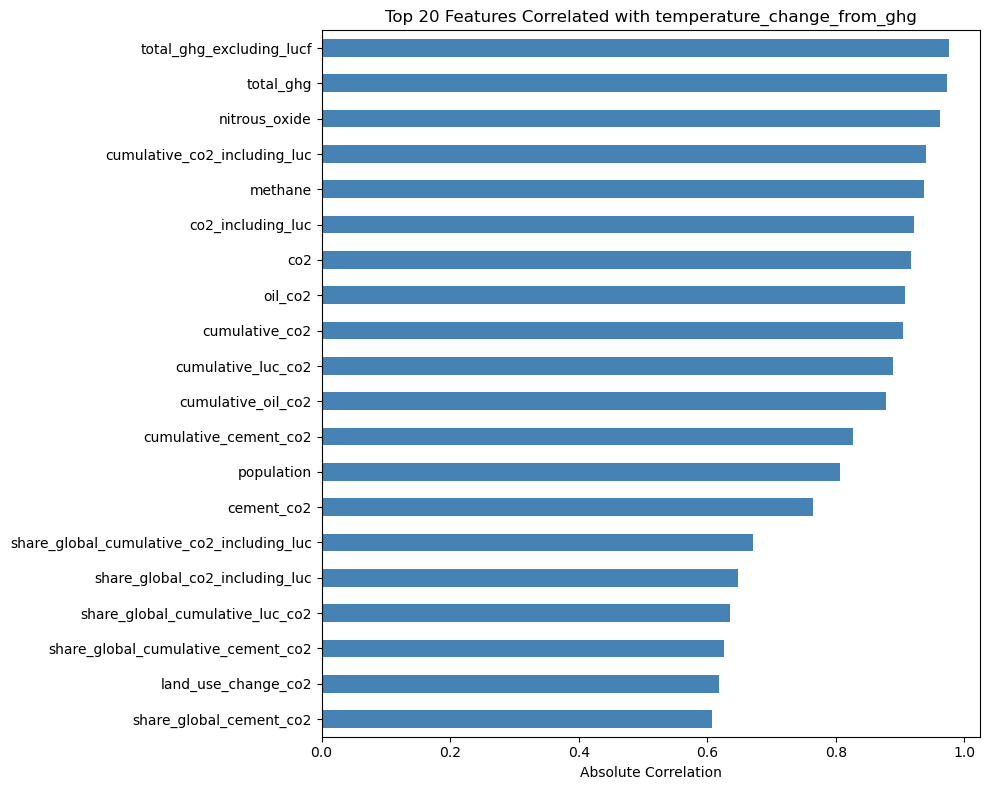

In [58]:
# Visualize top 20
plt.figure(figsize=(10, 8))
target_corr[:20].plot(kind='barh', color='steelblue')
plt.title("Top 20 Features Correlated with temperature_change_from_ghg")
plt.xlabel("Absolute Correlation")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [59]:
low_corr_cols = target_corr[target_corr < 0.01].index.tolist()
print(f"Low correlation columns to drop ({len(low_corr_cols)}):\n", low_corr_cols)

X = X.drop(columns=low_corr_cols, errors='ignore')
print("\nX shape after dropping low correlation features:", X.shape)

Low correlation columns to drop (0):
 []

X shape after dropping low correlation features: (41238, 35)


In [60]:
corr_matrix = X.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

highly_correlated = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col] > 0.95)
]

print(f"Highly correlated columns to drop ({len(highly_correlated)}):\n", highly_correlated)

X = X.drop(columns=highly_correlated, errors='ignore')
print("\nFinal X shape after feature selection:", X.shape)

Highly correlated columns to drop (14):
 ['co2_including_luc', 'cumulative_co2_including_luc', 'cumulative_luc_co2', 'cumulative_oil_co2', 'nitrous_oxide', 'oil_co2', 'share_global_cumulative_cement_co2', 'share_global_cumulative_co2', 'share_global_cumulative_co2_including_luc', 'share_global_cumulative_luc_co2', 'share_global_luc_co2', 'share_global_oil_co2', 'total_ghg', 'total_ghg_excluding_lucf']

Final X shape after feature selection: (41238, 21)


In [61]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFinal features:\n", X.columns.tolist())

# Confirm target is safe
print("\nTarget sample:")
print(y.head())

X shape: (41238, 21)
y shape: (41238,)

Final features:
 ['year', 'population', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_including_luc_growth_abs', 'co2_including_luc_per_capita', 'co2_per_capita', 'cumulative_cement_co2', 'cumulative_co2', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'land_use_change_co2_per_capita', 'methane', 'nitrous_oxide_per_capita', 'share_global_cement_co2', 'share_global_co2', 'share_global_co2_including_luc', 'share_global_cumulative_oil_co2']

Target sample:
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: temperature_change_from_ghg, dtype: float64


#### What I've learnt:
- Data leakage is one of the most dangerous mistakes in ML — always ask "would I have this column at prediction time in the real world?" If no, drop it
- Separate X and y as early as possible — it prevents the target from ever being accidentally dropped, filtered, or transformed during feature selection
- `corrwith()` is safer than `.corr()` for feature-target correlation because it operates on X and y independently — the target can never accidentally end up in low_corr_cols

## Step 5: Feature Engineering
**Concept**: Feature engineering is the process of creating new meaningful features from existing ones, or transforming existing features to make them more useful for the model. It's where domain knowledge meets data science.
**Why necessary**:

- Raw features don't always capture the full story in the data
- Models learn better from well-constructed features than raw numbers
- Can significantly boost model performance without adding more data
- Demonstrates deeper understanding of the dataset

**Strategies for this dataset**:

- Decade feature — group years into decades to capture emission trends over time
- CO2 per energy unit — already exists but we'll verify it's in our feature set
- Emission intensity ratio — how much GHG relative to total CO2
- Log transformation — some emission columns are heavily skewed, log smooths them out

In [62]:
# Group years into decades — captures era-level emission trends
X['decade'] = (X['year'] // 10) * 10

print("Decades in dataset:", sorted(X['decade'].unique()))

Decades in dataset: [np.float64(1850.0), np.float64(1860.0), np.float64(1870.0), np.float64(1880.0), np.float64(1890.0), np.float64(1900.0), np.float64(1910.0), np.float64(1920.0), np.float64(1930.0), np.float64(1940.0), np.float64(1950.0), np.float64(1960.0), np.float64(1970.0), np.float64(1980.0), np.float64(1990.0), np.float64(2000.0), np.float64(2010.0), np.float64(2020.0)]


In [64]:
print('total_ghg' in X.columns)

False


In [66]:
# GHG to CO2 ratio — only create if both columns exist
if 'total_ghg' in X.columns and 'co2' in X.columns:
    X['ghg_to_co2_ratio'] = np.where(
        X['co2'] > 0,
        X['total_ghg'] / X['co2'],
        0
    )
    print("ghg_to_co2_ratio created ✅")
else:
    # Use available GHG per capita columns instead
    if 'ghg_per_capita' in X.columns and 'co2_per_capita' in X.columns:
        X['ghg_to_co2_ratio'] = np.where(
            X['co2_per_capita'] > 0,
            X['ghg_per_capita'] / X['co2_per_capita'],
            0
        )
        print("ghg_to_co2_ratio created using per_capita columns")
    else:
        print("Skipping ghg_to_co2_ratio — required columns not available")

ghg_to_co2_ratio created using per_capita columns


In [67]:
# Identify highly skewed numeric columns
skewness = X.skew().sort_values(ascending=False)
highly_skewed = skewness[skewness.abs() > 1].index.tolist()

print(f"Highly skewed columns ({len(highly_skewed)}):\n", highly_skewed)

Highly skewed columns (21):
 ['co2_per_capita', 'ghg_to_co2_ratio', 'cumulative_cement_co2', 'cement_co2', 'cumulative_co2', 'co2', 'population', 'ghg_excluding_lucf_per_capita', 'land_use_change_co2_per_capita', 'methane', 'co2_including_luc_per_capita', 'share_global_cement_co2', 'nitrous_oxide_per_capita', 'land_use_change_co2', 'share_global_co2_including_luc', 'share_global_cumulative_oil_co2', 'co2_growth_abs', 'share_global_co2', 'ghg_per_capita', 'cement_co2_per_capita', 'co2_including_luc_growth_abs']


In [69]:
# Apply log1p transformation (log1p handles zeros safely)
for col in highly_skewed:
    X[col] = np.log1p(X[col].clip(lower=0))  # clip negatives to 0 first

print("Log transformation applied to skewed columns.")

Log transformation applied to skewed columns.


In [70]:
print("New features added:")
print([col for col in X.columns if col in ['decade', 'ghg_to_co2_ratio']])

print("\nUpdated X shape:", X.shape)
print("\nSample of engineered features:")
X[['year', 'decade', 'ghg_to_co2_ratio']].head(10)

New features added:
['decade', 'ghg_to_co2_ratio']

Updated X shape: (41238, 23)

Sample of engineered features:


,year,decade,ghg_to_co2_ratio
0,1851.0,1850.0,0.691541
1,1852.0,1850.0,0.692790
2,1853.0,1850.0,0.693724
3,1854.0,1850.0,0.694656
4,1855.0,1850.0,0.695585
5,1856.0,1850.0,0.696357
6,1857.0,1850.0,0.697127
7,1858.0,1850.0,0.697743
8,1859.0,1850.0,0.698356
9,1860.0,1860.0,0.699581


In [71]:
# Confirm no NaN or infinite values crept in
print("NaN values in X:", X.isnull().sum().sum())
print("Infinite values in X:", np.isinf(X).sum().sum())

# Replace any infinite values that log transform may have missed
X = X.replace([np.inf, -np.inf], 0)

print("\nAfter cleanup:")
print("NaN values in X:", X.isnull().sum().sum())
print("Infinite values in X:", np.isinf(X).sum().sum())
print("Final X shape:", X.shape)

NaN values in X: 0
Infinite values in X: 0

After cleanup:
NaN values in X: 0
Infinite values in X: 0
Final X shape: (41238, 23)


What I've learnt:

Feature engineering is where creativity meets data science — there's no single right answer, you experiment and validate
log1p is the safe standard for transforming right-skewed emission data
Always check for NaN and inf after any transformation — they can appear silently
Creating a decade feature is a simple but powerful way to help a model understand time-based trends without treating every year as completely unique
np.where(condition, value_if_true, value_if_false) is the vectorized way to do conditional column creation — much faster than loops

## Step 6: Train/Test Split
**Concept**: Splitting your data into a training set and a test set simulates how your model will perform on data it has never seen before. You train on one portion and evaluate on the other.
**Why necessary**:

- If you train and test on the same data, your model scores perfectly but fails in the real world — this is called overfitting
- The test set acts as a "final exam" — the model never sees it during training
- Gives you an honest estimate of real-world model performance
- Standard industry practice — no ML project skips this step

**Strategies for this dataset**:

80/20 split — 80% training, 20% testing. With 40,000+ rows we have enough data for this to be reliable
random_state=42 — fixes the random seed so your split is reproducible every time you run the notebook
shuffle=True — ensures data is randomly mixed before splitting since our data is ordered by country and year


In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # reproducibility
    shuffle=True         # mix before splitting
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (32990, 23)
X_test shape: (8248, 23)
y_train shape: (32990,)
y_test shape: (8248,)


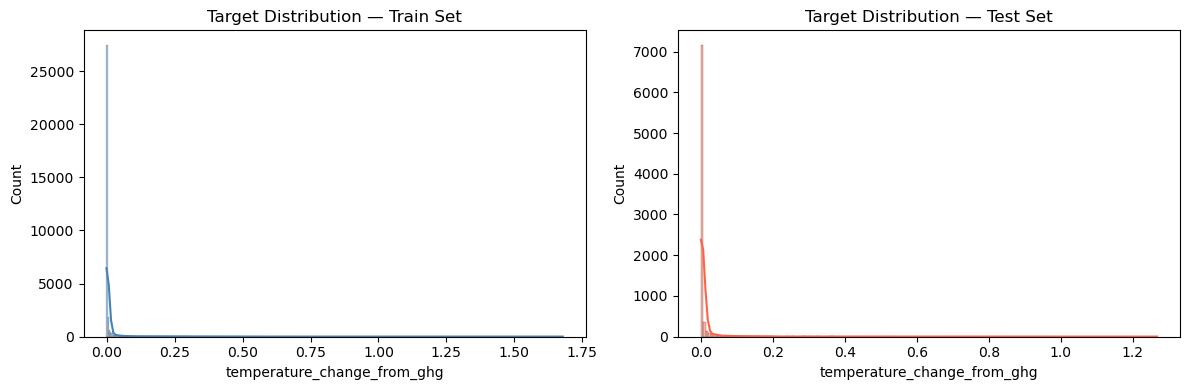

Train target mean: 0.0116
Test target mean: 0.0097


In [73]:
# Check that target distribution is similar in train and test
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(y_train, kde=True, color='steelblue')
plt.title("Target Distribution — Train Set")

plt.subplot(1, 2, 2)
sns.histplot(y_test, kde=True, color='tomato')
plt.title("Target Distribution — Test Set")

plt.tight_layout()
plt.show()

print("Train target mean:", y_train.mean().round(4))
print("Test target mean:", y_test.mean().round(4))

In [74]:
# Confirm train and test indices don't overlap
train_idx = set(X_train.index)
test_idx = set(X_test.index)

overlap = train_idx.intersection(test_idx)
print("Index overlap between train and test:", len(overlap))
# Should print 0 — any overlap means leakage

Index overlap between train and test: 0


What I've learnt:

The train/test split is your model's integrity check — without it you have no way of knowing if your model actually learned anything
random_state=42 is a convention in the data science community — it makes your results reproducible so others can verify your work
shuffle=True is critical for this dataset because the data is sorted by country and year — without shuffling, your test set would only contain recent years which biases evaluation
The four variables X_train, X_test, y_train, y_test are universal naming conventions in ML — any data scientist will immediately understand what they represent
Always verify that train and test target distributions match — a mismatch is a sign something went wrong in your split

## Step 7: Feature Scaling
**Concept**: Feature scaling transforms all numeric features to the same scale. Without it, a column with values in the millions (like co2) dominates a column with values between 0 and 1 (like share_global_co2), causing the model to unfairly weight larger numbers.
**Why necessary**:

Regression models are sensitive to the magnitude of feature values
Features on different scales cause the model to assign wrong importance to features
Scaling speeds up model training significantly
Required for distance-based and gradient-based algorithms to work correctly
Makes model coefficients comparable across features

**Strategies for this dataset**:

StandardScaler — transforms each feature to have mean=0 and std=1. Best choice for regression with normally distributed features
Fit on training data only — then transform both train and test. Fitting on test data would be leakage
Never fit the scaler on the full dataset before splitting — that leaks test set statistics into training

In [76]:
# Initialize scaler
scaler = StandardScaler()

# Fit ONLY on training data — never on full dataset or test set
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # transform only, no fit

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (32990, 23)
X_test_scaled shape: (8248, 23)


In [77]:
# Convert back to dataframe for readability
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

print("Mean of each feature (should be ~0):")
print(X_train_scaled_df.mean().round(3).head(10))

print("\nStd of each feature (should be ~1):")
print(X_train_scaled_df.std().round(3).head(10))

Mean of each feature (should be ~0):
year                            0.0
population                      0.0
cement_co2                     -0.0
cement_co2_per_capita           0.0
co2                            -0.0
co2_growth_abs                 -0.0
co2_including_luc_growth_abs   -0.0
co2_including_luc_per_capita   -0.0
co2_per_capita                  0.0
cumulative_cement_co2          -0.0
dtype: float64

Std of each feature (should be ~1):
year                            1.0
population                      1.0
cement_co2                      1.0
cement_co2_per_capita           1.0
co2                             1.0
co2_growth_abs                  1.0
co2_including_luc_growth_abs    1.0
co2_including_luc_per_capita    1.0
co2_per_capita                  1.0
cumulative_cement_co2           1.0
dtype: float64


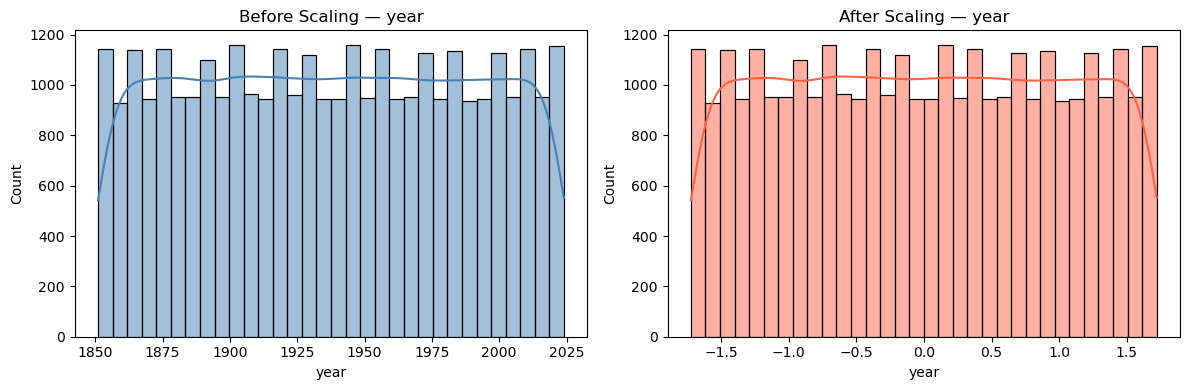

In [78]:
# Visualize distribution of a few features before and after scaling
# Pick one feature to visualize the effect of scaling
sample_col = X_train.columns[0]
sample_idx = X_train.columns.tolist().index(sample_col)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(X_train[sample_col], kde=True, color='steelblue')
plt.title(f"Before Scaling — {sample_col}")

plt.subplot(1, 2, 2)
sns.histplot(X_train_scaled_df[sample_col], kde=True, color='tomato')
plt.title(f"After Scaling — {sample_col}")

plt.tight_layout()
plt.show()

What I've learnt:

Always fit the scaler on training data only — fitting on test or full data is one of the most common and subtle forms of data leakage
fit_transform() does two things at once — learns the statistics (fit) and applies the transformation (transform). On test data you only call transform() because the statistics are already learned
StandardScaler doesn't change the shape of your distribution — it just shifts and rescales it. A skewed feature stays skewed, it's just on a new scale
Not all models need scaling — tree-based models like Random Forest and Gradient Boosting are scale-invariant. But it never hurts to scale anyway, and it's required for Linear Regression and Ridge
Always keep the scaler object saved — you'll need it later to scale new data before making predictions with your saved model

## Step 8: Training Models
**Concept**: This is where you actually build your ML models. You'll train multiple models on the same data and compare them — a standard industry practice called model comparison. No single algorithm is always best, so you let the data decide.
**Why necessary**:

Different algorithms learn patterns differently — one may suit your data better than others
Training multiple models gives you a benchmark to compare against
Helps you understand the tradeoff between model simplicity and performance
A portfolio project with multiple models shows hiring managers you understand the ML landscape

**Models we'll train**:
| Model                     | Type               | Why include it                                                    |
| ------------------------- | ------------------ | ----------------------------------------------------------------- |
| LinearRegression          | Simple baseline    | Every project needs a baseline to beat                            |
| Ridge                     | Regularized linear | Handles multicollinearity better than plain linear regression     |
| DecisionTreeRegressor     | Tree-based         | Captures nonlinear patterns and is easy to interpret              |
| RandomForestRegressor     | Ensemble           | Usually a top performer and robust to overfitting                 |
| GradientBoostingRegressor | Ensemble           | Often achieves the best accuracy by learning from previous errors |


In [79]:

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

print("Models defined")
print("Total models to train:", len(models))

Models defined
Total models to train: 5


In [80]:

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions on test set
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    }
    
    print(f" {name} — R2: {r2:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")

print("\nAll models trained ✅")

Training Linear Regression...
 Linear Regression — R2: 0.3869 | MAE: 0.0157 | RMSE: 0.0401
Training Ridge Regression...
 Ridge Regression — R2: 0.3869 | MAE: 0.0157 | RMSE: 0.0401
Training Decision Tree...
 Decision Tree — R2: 0.9907 | MAE: 0.0009 | RMSE: 0.0049
Training Random Forest...
 Random Forest — R2: 0.9933 | MAE: 0.0003 | RMSE: 0.0042
Training Gradient Boosting...
 Gradient Boosting — R2: 0.9938 | MAE: 0.0011 | RMSE: 0.0040

All models trained ✅


In [81]:
results_df = pd.DataFrame(results).T.sort_values('R2 Score', ascending=False)
print(results_df)

                      MAE    RMSE  R2 Score
Gradient Boosting  0.0011  0.0040    0.9938
Random Forest      0.0003  0.0042    0.9933
Decision Tree      0.0009  0.0049    0.9907
Linear Regression  0.0157  0.0401    0.3869
Ridge Regression   0.0157  0.0401    0.3869


In [82]:

# Get the best model name based on R2
best_model_name = results_df.index[0]
best_model = models[best_model_name]

print(f"Best model: {best_model_name}")
print("Running 5-fold cross validation...\n")

cv_scores = cross_val_score(
    best_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print(f"CV R2 Scores: {cv_scores.round(4)}")
print(f"Mean CV R2: {cv_scores.mean().round(4)}")
print(f"Std CV R2: {cv_scores.std().round(4)}")

Best model: Gradient Boosting
Running 5-fold cross validation...

CV R2 Scores: [0.9855 0.9972 0.9963 0.9959 0.9962]
Mean CV R2: 0.9942
Std CV R2: 0.0044


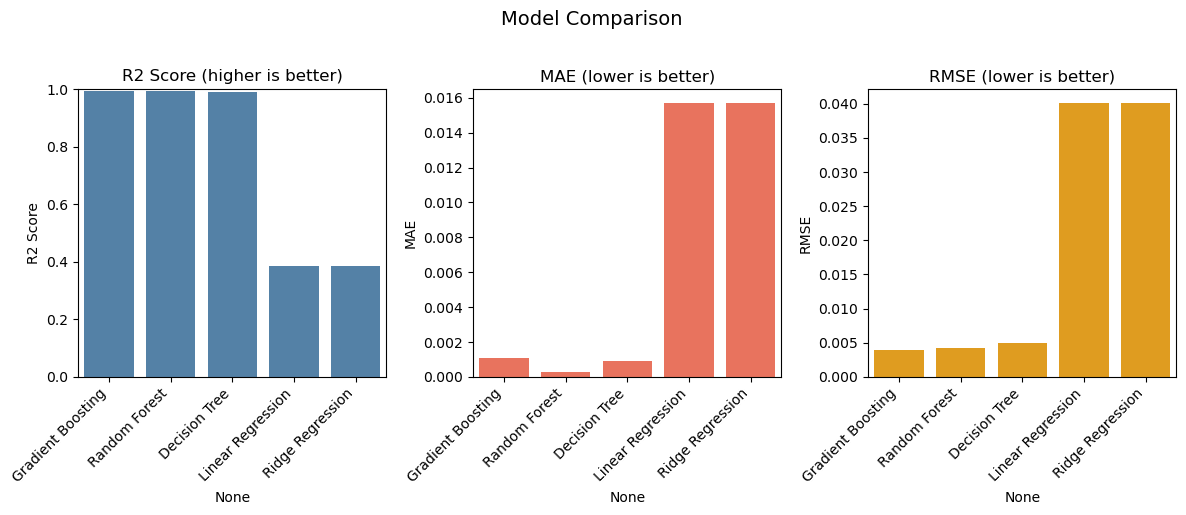

In [84]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
sns.barplot(x=results_df.index, y=results_df['R2 Score'], color='steelblue')
plt.title("R2 Score (higher is better)")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)

plt.subplot(1, 3, 2)
sns.barplot(x=results_df.index, y=results_df['MAE'], color='tomato')
plt.title("MAE (lower is better)")
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 3, 3)
sns.barplot(x=results_df.index, y=results_df['RMSE'], color='orange')
plt.title("RMSE (lower is better)")
plt.xticks(rotation=45, ha='right')

plt.suptitle("Model Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

What I've learnt:

Always train a baseline model (Linear Regression) first — if your complex model can't beat a straight line, something is wrong with your data or features
R2 Score is the most intuitive regression metric for portfolio projects — it's easy to explain to non-technical stakeholders ("my model explains 92% of the variance")
Cross validation gives a more honest performance estimate than a single train/test split — a model that scores well on CV is genuinely good, not just lucky
n_jobs=-1 is a simple trick that can cut training time significantly on large datasets — always use it for Random Forest and Gradient Boosting
Storing results in a dictionary and converting to a DataFrame is a clean pattern for comparing multiple models — standard practice in real ML workflows
Ensemble models (Random Forest, Gradient Boosting) almost always outperform single models because they combine many weak learners into one strong learner

## Step 9: Evaluating Models
**Concept**: Evaluation goes deeper than just looking at metrics. You analyze how and where your model is making errors — not just how much. This step turns numbers into insight.
**Why necessary**:

A high R2 score alone doesn't tell the full story — your model could be great overall but terrible at predicting extreme values
Residual analysis reveals if your model has systematic errors or biases
Helps you decide if your best model is good enough for deployment
Demonstrates analytical depth in a portfolio project — anyone can print metrics, few actually interpret them

W**hat we'll evaluate**:

Actual vs Predicted plot — how close predictions are to the truth
Residual plot — pattern in errors reveals model weaknesses
Error distribution — are errors normally distributed or skewed
Feature importance — which features drove the model's decisions

In [85]:
# Use the best model identified in Step 8
best_model_name = results_df.index[0]
best_model = models[best_model_name]

# Generate predictions
y_pred = best_model.predict(X_test_scaled)

print(f"Evaluating: {best_model_name}")
print(f"R2 Score:  {r2_score(y_test, y_pred):.4f}")
print(f"MAE:       {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

Evaluating: Gradient Boosting
R2 Score:  0.9938
MAE:       0.0011
RMSE:      0.0040


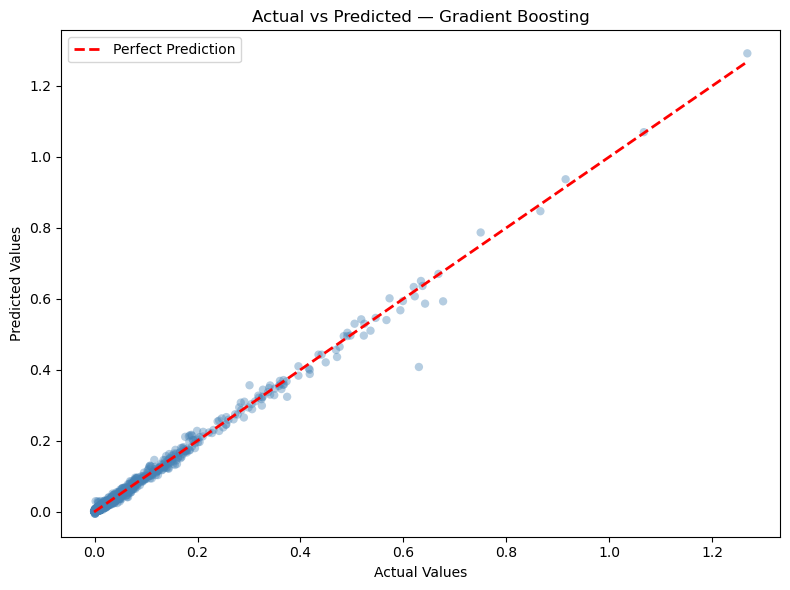

In [86]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='none')

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2, label='Perfect Prediction'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

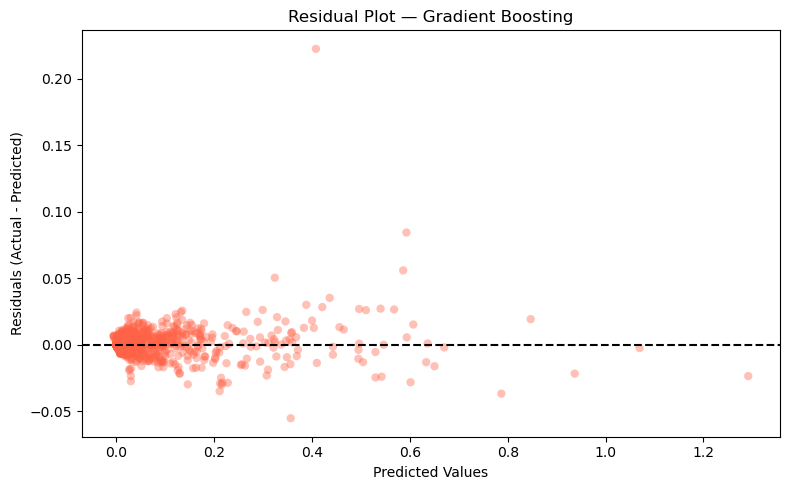

In [87]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.4, color='tomato', edgecolors='none')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title(f"Residual Plot — {best_model_name}")
plt.tight_layout()
plt.show()

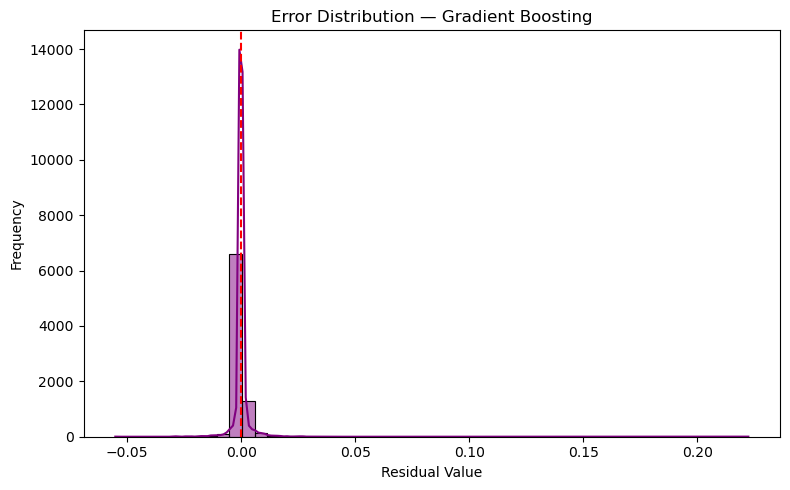

Residuals mean: 3.6e-05
Residuals std: 0.004


In [91]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='purple', bins=50)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.title(f"Error Distribution — {best_model_name}")
plt.tight_layout()
plt.show()

print("Residuals mean:", round(residuals.mean(), 6))
print("Residuals std:", round(residuals.std(), 4))

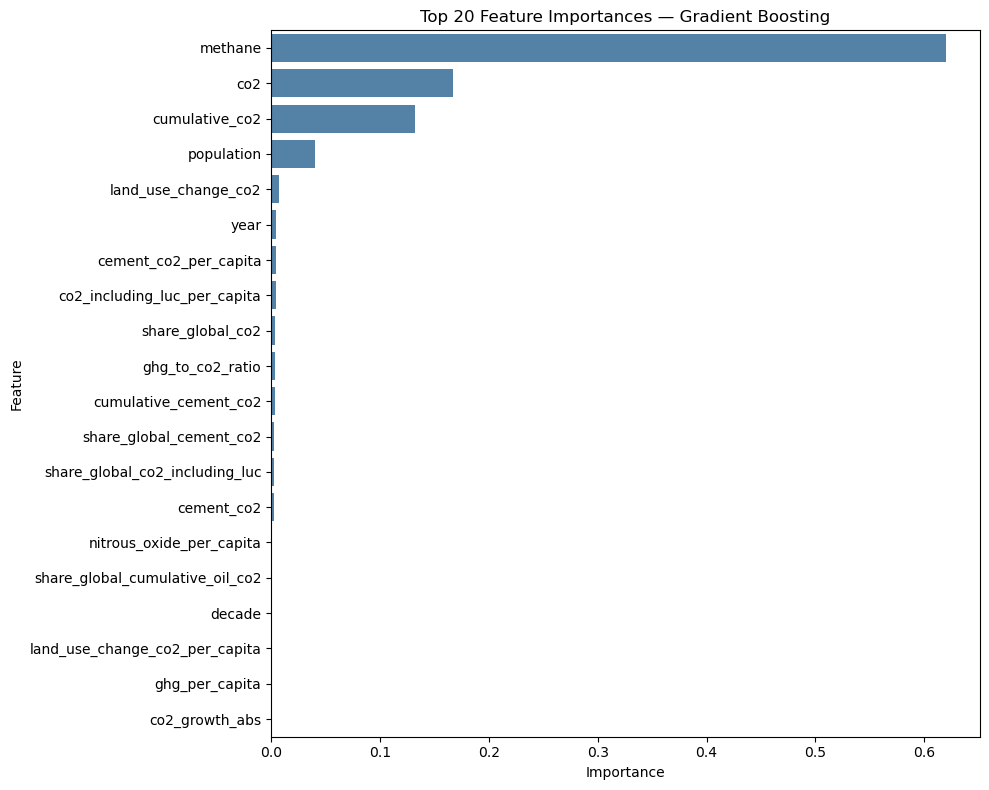

                            Feature  Importance
15                          methane    0.620136
4                               co2    0.167242
10                   cumulative_co2    0.132114
1                        population    0.039886
13              land_use_change_co2    0.007263
0                              year    0.004504
3             cement_co2_per_capita    0.004093
7      co2_including_luc_per_capita    0.004077
18                 share_global_co2    0.003984
22                 ghg_to_co2_ratio    0.003716
9             cumulative_cement_co2    0.003155
17          share_global_cement_co2    0.002643
19   share_global_co2_including_luc    0.002396
2                        cement_co2    0.002328
16         nitrous_oxide_per_capita    0.000811
20  share_global_cumulative_oil_co2    0.000590
21                           decade    0.000447
14   land_use_change_co2_per_capita    0.000379
12                   ghg_per_capita    0.000173
5                    co2_growth_abs    0

In [92]:
# Feature importance only available for tree based models
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(20)

    plt.figure(figsize=(10, 8))
    sns.barplot(
        x='Importance',
        y='Feature',
        data=importance_df,
        color='steelblue'
    )
    plt.title(f"Top 20 Feature Importances — {best_model_name}")
    plt.tight_layout()
    plt.show()

    print(importance_df)
else:
    print(f"{best_model_name} does not support feature importances directly")
    print("Consider using permutation importance instead")

In [93]:
# Show a sample comparison of actual vs predicted
eval_df = pd.DataFrame({
    'Actual': y_test.values[:20],
    'Predicted': y_pred[:20],
    'Error': (y_test.values[:20] - y_pred[:20]).round(4),
    'Abs Error': abs(y_test.values[:20] - y_pred[:20]).round(4)
})

print(eval_df.to_string(index=False))

 Actual  Predicted   Error  Abs Error
  0.000   0.000097 -0.0001     0.0001
  0.005   0.001055  0.0039     0.0039
  0.000   0.000670 -0.0007     0.0007
  0.001   0.001490 -0.0005     0.0005
  0.001   0.000674  0.0003     0.0003
  0.000   0.000299 -0.0003     0.0003
  0.010   0.010239 -0.0002     0.0002
  0.000   0.000097 -0.0001     0.0001
  0.006   0.005988  0.0000     0.0000
  0.002   0.001559  0.0004     0.0004
  0.000   0.000097 -0.0001     0.0001
  0.000   0.001160 -0.0012     0.0012
  0.000   0.000097 -0.0001     0.0001
  0.000   0.000186 -0.0002     0.0002
  0.000   0.000097 -0.0001     0.0001
  0.000   0.000384 -0.0004     0.0004
  0.000   0.000445 -0.0004     0.0004
  0.002   0.000426  0.0016     0.0016
  0.001   0.001655 -0.0007     0.0007
  0.001   0.000825  0.0002     0.0002


What I've learnt:

- Metrics alone are not evaluation — visualizing errors is what separates a junior from an experienced data scientist
- The actual vs predicted plot is the single most intuitive way to explain model performance to a non-technical audience
- Residuals should always be centered at zero and randomly scattered — any pattern means the model is missing something systematic in the data
- Feature importance bridges the gap between ML and domain knowledge — it tells you why the model works, not just that it works
- A model can have a good R2 score but still have a skewed error distribution — always check both
hasattr(model, 'feature_importances_') is a clean way to check if a model supports feature importance before calling it — prevents crashes when switching between model types